In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn

import torch.optim as optim

import torchvision
import torchvision.transforms as transforms 
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [50]:
import os

for root, dirs, files in os.walk("PetImages"):
    print(root, "->", len(files), "files")

PetImages -> 0 files
PetImages/Cat -> 5714 files
PetImages/Dog -> 5494 files


In [51]:
from PIL import Image

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.convert("RGB")
        return True
    except Exception:
        return False

In [52]:
# Transform 
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Dataset Banana

dataset = ImageFolder(root="PetImages", transform=transform, is_valid_file=is_valid_image)
print(dataset.classes)
print(len(dataset))


# train/val /test split

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

trainset, valset, testset = random_split(dataset, [train_size, val_size, test_size])
print(len(trainset), len(valset), len(testset))


# 4. DataLoader
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
valloader = DataLoader(valset, batch_size=32, shuffle=False)
testloader = DataLoader(testset, batch_size=32, shuffle=False)


['Cat', 'Dog']
11205
7843 1680 1682


# CNN 


In [53]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding =1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding =1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding =1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(16*16*128, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, x):
            x = self.conv_layers(x)
            x = x.view(x.size(0), -1)
            x = self.fc_layers(x)


            return x

In [54]:
model = CNN().to(device)

In [55]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [56]:
epochs = 10

train_losses = []
val_losses = []
best_val_loss = float("inf")

for epoch in range(epochs):

    #  TRAINING 
    model.train()
    running_train_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(trainloader)
    train_losses.append(train_loss)

    # VALIDATION 
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_loss = running_val_loss / len(valloader)
    val_losses.append(val_loss)
    val_acc = correct / total * 100

    print(f"epoch = {epoch+1}/{epochs} | train loss = {train_loss:.4f} | val loss = {val_loss:.4f} | val acc = {val_acc:.2f}%")

    # ---------- BEST MODEL SAVE ----------
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch = 1/10 | train loss = 0.6461 | val loss = 0.5710 | val acc = 70.60%
epoch = 2/10 | train loss = 0.5498 | val loss = 0.5401 | val acc = 74.64%
epoch = 3/10 | train loss = 0.4863 | val loss = 0.4762 | val acc = 77.50%
epoch = 4/10 | train loss = 0.4294 | val loss = 0.4573 | val acc = 78.69%
epoch = 5/10 | train loss = 0.3779 | val loss = 0.4607 | val acc = 79.82%
epoch = 6/10 | train loss = 0.3221 | val loss = 0.4490 | val acc = 80.06%
epoch = 7/10 | train loss = 0.2390 | val loss = 0.5268 | val acc = 79.58%
epoch = 8/10 | train loss = 0.1382 | val loss = 0.5987 | val acc = 79.29%
epoch = 9/10 | train loss = 0.0728 | val loss = 0.7128 | val acc = 78.57%
epoch = 10/10 | train loss = 0.0384 | val loss = 1.0886 | val acc = 78.75%


Accuracy  = 77.65%
Precision = 0.7721
Recall    = 0.7366
Confusion Matrix:
[[730 170]
 [206 576]]


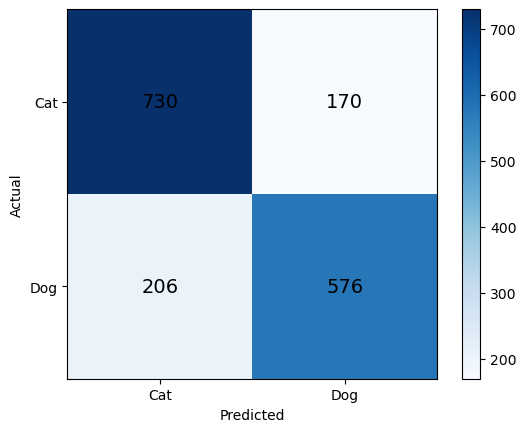

In [57]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())    
        all_labels.extend(labels.numpy())

# metrics
acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print(f"Accuracy  = {acc*100:.2f}%")
print(f"Precision = {prec:.4f}")
print(f"Recall    = {rec:.4f}")
print("Confusion Matrix:")
print(cm)

# confusion matrix  plot 
plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1], ["Cat", "Dog"])
plt.yticks([0, 1], ["Cat", "Dog"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i][j], ha="center", va="center", fontsize=14)
plt.colorbar()
plt.show()